In [115]:
import numpy as np
import pandas as pd

In [116]:
df=pd.read_csv("/content/Unified_Leads.csv")
df

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Name,contact_number,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,references,campaign_name,source_type,source_name
0,Anjali Singh,9931980478,anjali.singh878@hotmail.com,03-02-2026 22:31,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,Kiran Bose,6474315136,kiran.bose601@example.com,03-02-2026 21:46,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,Karthik Malhotra,6753707898,karthik.malhotra329@example.com,03-02-2026 21:28,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,Anjali Sharma,9439163624,anjali.sharma85@example.com,03-02-2026 19:59,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,Sneha Kapoor,9878269840,sneha.kapoor46@gmail.com,03-02-2026 19:19,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27370,Rohit Reddy,6992973331,rohit.reddy220@hotmail.com,02-06-2025 13:14,02-06-2025 14:46,CLOSED,LOST,not-interested,Riswana,02-06-2025 14:46,2:46 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27371,Kiran Shetty,9410734029,kiran.shetty925@outlook.com,02-06-2025 13:05,NaN,CLOSED,LOST,lost-to-competition,Anshad,NaN,NaN,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27372,Neha Shetty,9508547875,neha.shetty6@example.com,02-06-2025 12:39,02-06-2025 13:13,CLOSED,CONVERTED,NaN,Anshad,02-06-2025 13:13,1:13 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27373,Nikhil Yadav,7870690595,nikhil.yadav620@outlook.com,02-06-2025 12:35,02-06-2025 13:01,RESCHEDULED BY EXECUTIVE,Follow Up Required,cold,Anshad,02-06-2025 13:01,1:01 PM,NaN,Business Accounting,INSTAGRAM,INSTAGRAM


In [117]:
df.columns

Index(['Name', 'contact_number', 'Contact_email', 'creation_date',
       'first_call_attempt', 'lead_status', 'lead_stage', 'lead_tag',
       'assigned_to', 'last_call_date', 'last_call_time', 'references',
       'campaign_name', 'source_type', 'source_name'],
      dtype='object')

In [118]:
df['lead_status'].value_counts()

,count
lead_status,
CLOSED,12279
PENDING WITH EXECUTIVE,7947
NOT CONNECTED - RESCHEDULED BY SYSTEM,3857
RESCHEDULED BY EXECUTIVE,2962
NOT CONNECTED - CLOSED BY SYSTEM,328
OPEN,2


In [119]:
df['lead_stage'].value_counts()

,count
lead_stage,
LOST,11698
Prospect,10119
Follow Up Required,4713
CONVERTED,845


lead stage is target

In [120]:
df['lead_tag'].value_counts()

,count
lead_tag,
not-interested,10869
cold,4024
warm,446
lost-to-competition,303
hot,236
call-not-connected,52
already-purchased,29


In [121]:
df['references'].value_counts()

,count
references,


In [122]:
print(df['references'].isna().sum())
print(df['references'].notna().sum())

27375
0


drop references

In [123]:
df.drop('references',axis=1,inplace=True)


In [124]:
df.isna().sum()

,0
Name,0
contact_number,0
Contact_email,0
creation_date,0
first_call_attempt,6729
lead_status,0
lead_stage,0
lead_tag,11416
assigned_to,0
last_call_date,6729


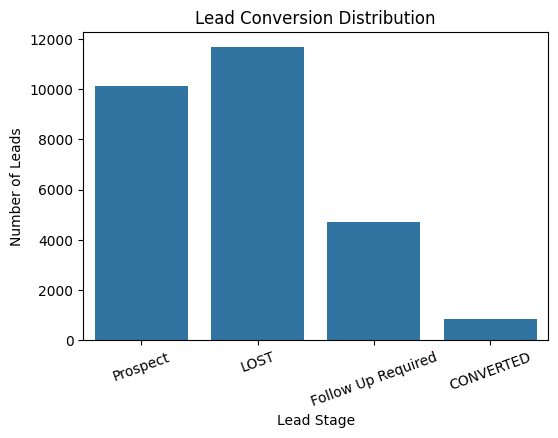

In [125]:
#data analysis
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='lead_stage')
plt.title('Lead Conversion Distribution')
plt.xlabel('Lead Stage')
plt.ylabel('Number of Leads')
plt.xticks(rotation=20)
plt.show()

source_type
FACEBOOK_ADS        3.604359
FILE_UPLOAD         0.311891
INSTAGRAM           4.218458
MOVE_LEAD           0.632022
NEODOVE_DIAL_PAD    0.000000
WALK_IN_LEAD        4.761905
Name: lead_stage, dtype: float64


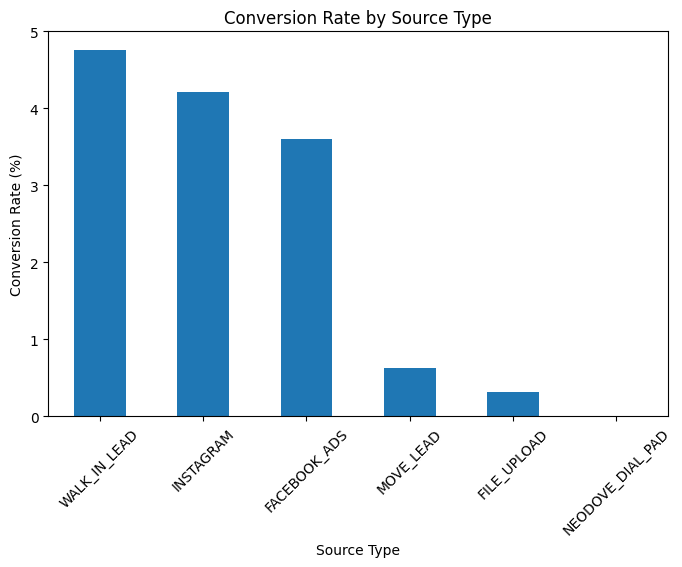

In [126]:
conversion_rate = df.groupby('source_type')['lead_stage'].apply(lambda x: (x == 'CONVERTED').mean() * 100)
print(conversion_rate)
conversion_rate.sort_values(ascending=False).plot(kind='bar',figsize=(8,5))
plt.title('Conversion Rate by Source Type')
plt.xlabel('Source Type')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.show()

campaign_name
Business Accounting                     21.066368
Common Ads 21-08-2025                    2.654867
Refurbished Campaign- UI/UX              2.127660
Python Knovista New                      2.088773
UI/UX no Stipend                         2.040816
DM NO-STIPEND-23-10-2025                 1.886792
Python Knovista                          1.880531
Python Knovista No Stipend               1.851852
SAP COURSE - 20-10-2025                  1.840491
Data Analytics Knovista                  1.628756
UI/UX Hiring                             1.525054
Performance Marketing Knovista           1.307190
BA NO STIPEND 28-10-2025                 1.282051
PHP Knovista                             1.228501
Refurbished Campaign-DA                  1.066667
BA NEW 18-08-2025                        0.999092
Refurbished Campaign-BA                  0.817996
Digital Marketing Knovista               0.745527
IT DUMB                                  0.709220
PHP Knovista New                    

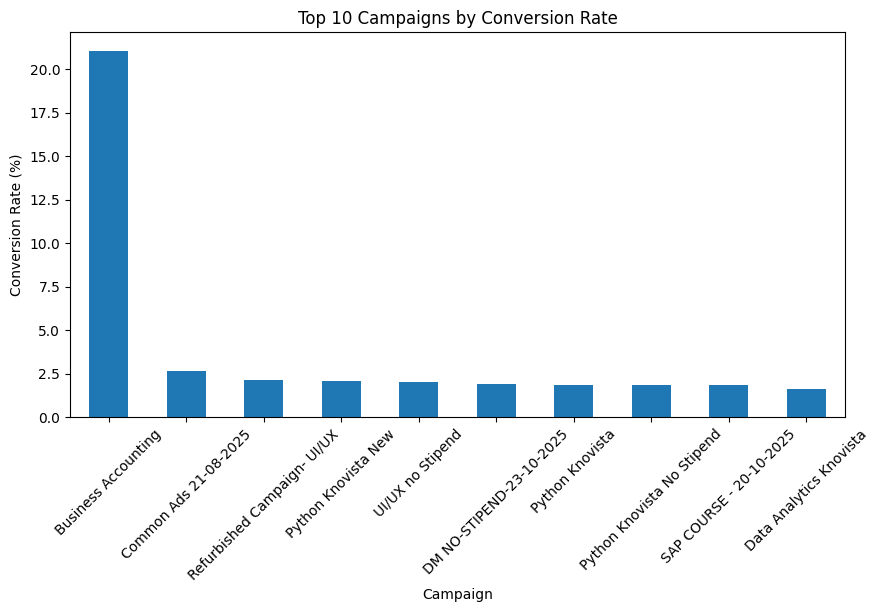

In [127]:
conversion_rate_campaign = df.groupby('campaign_name')['lead_stage'].apply(lambda x: (x == 'CONVERTED').mean() * 100)
print(conversion_rate_campaign.sort_values(ascending=False))
conversion_rate_campaign.sort_values(ascending=False).head(10).plot(kind='bar',figsize=(10,5))
plt.title('Top 10 Campaigns by Conversion Rate')
plt.xlabel('Campaign')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [128]:
pd.crosstab(df['lead_status'], df['lead_stage'])

lead_stage,CONVERTED,Follow Up Required,LOST,Prospect
lead_status,,,,
CLOSED,845,0,11362,72
NOT CONNECTED - CLOSED BY SYSTEM,0,0,328,0
NOT CONNECTED - RESCHEDULED BY SYSTEM,0,456,8,3393
OPEN,0,0,0,2
PENDING WITH EXECUTIVE,0,1695,0,6252
RESCHEDULED BY EXECUTIVE,0,2562,0,400


In [129]:
pd.crosstab(df['lead_tag'], df['lead_stage'])


lead_stage,Follow Up Required,LOST
lead_tag,,
already-purchased,0,29
call-not-connected,0,52
cold,4024,0
hot,236,0
lost-to-competition,0,303
not-interested,0,10869
warm,446,0


In [130]:
df.drop(['lead_status','lead_tag'],axis=1,inplace=True)

lead_status and lead_tag are dropped because they contain information closely related to the lead's final outcome. This may lead to target leakage.

In [131]:
df.drop(['Name', 'contact_number', 'Contact_email'],axis=1,inplace=True)#no need for prediction
df

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,creation_date,first_call_attempt,lead_stage,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name
0,03-02-2026 22:31,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,03-02-2026 21:46,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,03-02-2026 21:28,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,03-02-2026 19:59,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,03-02-2026 19:19,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
...,...,...,...,...,...,...,...,...,...
27370,02-06-2025 13:14,02-06-2025 14:46,LOST,Riswana,02-06-2025 14:46,2:46 PM,Business Accounting,INSTAGRAM,INSTAGRAM
27371,02-06-2025 13:05,NaN,LOST,Anshad,NaN,NaN,Business Accounting,INSTAGRAM,INSTAGRAM
27372,02-06-2025 12:39,02-06-2025 13:13,CONVERTED,Anshad,02-06-2025 13:13,1:13 PM,Business Accounting,INSTAGRAM,INSTAGRAM
27373,02-06-2025 12:35,02-06-2025 13:01,Follow Up Required,Anshad,02-06-2025 13:01,1:01 PM,Business Accounting,INSTAGRAM,INSTAGRAM


In [132]:
df.isna().sum()

,0
creation_date,0
first_call_attempt,6729
lead_stage,0
assigned_to,0
last_call_date,6729
last_call_time,6729
campaign_name,0
source_type,0
source_name,0


In [133]:
df.dtypes

,0
creation_date,object
first_call_attempt,object
lead_stage,object
assigned_to,object
last_call_date,object
last_call_time,object
campaign_name,object
source_type,object
source_name,object


In [134]:
df.head()

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,creation_date,first_call_attempt,lead_stage,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name
0,03-02-2026 22:31,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,03-02-2026 21:46,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,03-02-2026 21:28,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,03-02-2026 19:59,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,03-02-2026 19:19,NaN,Prospect,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM


In [135]:
print(df['last_call_time'].dropna().head(10))

594    12:31 PM
607     1:11 PM
614    12:58 PM
616     1:11 PM
632     3:14 PM
637     3:29 PM
638     4:12 PM
645    11:36 AM
646     4:13 PM
648    11:50 AM
Name: last_call_time, dtype: object


In [136]:
print(df['last_call_date'].dropna().head())

594    26-12-2025 12:31
607    25-12-2025 13:11
614    25-12-2025 12:58
616    25-12-2025 13:11
632    25-12-2025 15:14
Name: last_call_date, dtype: object


last_call_date already contains time ,so drop last_call_time

In [137]:
df.drop('last_call_time',axis=1,inplace=True)#last_call_date already contains time

In [138]:
df['first_call_attempt']=pd.to_datetime(df['first_call_attempt'],format='%d-%m-%Y %H:%M')
df['creation_date']=pd.to_datetime(df['creation_date'],format='%d-%m-%Y %H:%M')
df['last_call_date']=pd.to_datetime(df['last_call_date'],format='%d-%m-%Y %H:%M')

In [139]:
df.dtypes

,0
creation_date,datetime64[ns]
first_call_attempt,datetime64[ns]
lead_stage,object
assigned_to,object
last_call_date,datetime64[ns]
campaign_name,object
source_type,object
source_name,object


In [140]:
df=pd.get_dummies(df,columns=['assigned_to','campaign_name','source_type','source_name'],drop_first=True)
df

,creation_date,first_call_attempt,lead_stage,last_call_date,assigned_to_Akhil M A,assigned_to_Amghitha,assigned_to_Anandhakrishnan,assigned_to_Anshad,assigned_to_Ardra,assigned_to_Ardra Shibu,...,source_name_hhhh.xlsx/Sheet1,source_name_new.xlsx/BA _ KL _ July 23_Leads_2025-08,source_name_pm5-8.xlsx/pm 5-8,source_name_python new.xlsx/DA _ KL _ Hiring _ Fee included,source_name_pythonnnn.xlsx/Sheet1,source_name_sap new.xlsx/SAP - KL - Hiring - 01-10-2025_,source_name_sss.xlsx/Sheet1,source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,source_name_weess.xlsx/Sheet1,source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202
0,2026-02-03 22:31:00,NaT,Prospect,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2026-02-03 21:46:00,NaT,Prospect,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2026-02-03 21:28:00,NaT,Prospect,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2026-02-03 19:59:00,NaT,Prospect,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2026-02-03 19:19:00,NaT,Prospect,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27370,2025-06-02 13:14:00,2025-06-02 14:46:00,LOST,2025-06-02 14:46:00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
27371,2025-06-02 13:05:00,NaT,LOST,NaT,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
27372,2025-06-02 12:39:00,2025-06-02 13:13:00,CONVERTED,2025-06-02 13:13:00,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
27373,2025-06-02 12:35:00,2025-06-02 13:01:00,Follow Up Required,2025-06-02 13:01:00,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [141]:
df.dtypes

,0
creation_date,datetime64[ns]
first_call_attempt,datetime64[ns]
lead_stage,object
last_call_date,datetime64[ns]
assigned_to_Akhil M A,bool
...,...
source_name_sap new.xlsx/SAP - KL - Hiring - 01-10-2025_,bool
source_name_sss.xlsx/Sheet1,bool
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,bool
source_name_weess.xlsx/Sheet1,bool


In [142]:
df.isna().sum()

,0
creation_date,0
first_call_attempt,6729
lead_stage,0
last_call_date,6729
assigned_to_Akhil M A,0
...,...
source_name_sap new.xlsx/SAP - KL - Hiring - 01-10-2025_,0
source_name_sss.xlsx/Sheet1,0
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,0
source_name_weess.xlsx/Sheet1,0


In [143]:
df['time_taken_to_first_call']=(df['first_call_attempt']-df['creation_date']).dt.total_seconds()/3600

In [144]:
df['time_taken_to_first_call']=df['time_taken_to_first_call'].fillna(-1)#-1 indicates no first call happened

In [145]:
df.isna().sum()

,0
creation_date,0
first_call_attempt,6729
lead_stage,0
last_call_date,6729
assigned_to_Akhil M A,0
...,...
source_name_sss.xlsx/Sheet1,0
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,0
source_name_weess.xlsx/Sheet1,0
source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,0


In [146]:
df.drop(['creation_date','first_call_attempt','last_call_date'],axis=1,inplace=True)

In [147]:
df.isna().sum()

,0
lead_stage,0
assigned_to_Akhil M A,0
assigned_to_Amghitha,0
assigned_to_Anandhakrishnan,0
assigned_to_Anshad,0
...,...
source_name_sss.xlsx/Sheet1,0
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,0
source_name_weess.xlsx/Sheet1,0
source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,0


In [148]:
df['lead_stage']=df['lead_stage'].map({'CONVERTED':1,'LOST':0,'Prospect':0,'Follow Up Required':0})
df

,lead_stage,assigned_to_Akhil M A,assigned_to_Amghitha,assigned_to_Anandhakrishnan,assigned_to_Anshad,assigned_to_Ardra,assigned_to_Ardra Shibu,assigned_to_Arunkumar,assigned_to_Ashna sathar,assigned_to_Asiya,...,source_name_new.xlsx/BA _ KL _ July 23_Leads_2025-08,source_name_pm5-8.xlsx/pm 5-8,source_name_python new.xlsx/DA _ KL _ Hiring _ Fee included,source_name_pythonnnn.xlsx/Sheet1,source_name_sap new.xlsx/SAP - KL - Hiring - 01-10-2025_,source_name_sss.xlsx/Sheet1,source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,source_name_weess.xlsx/Sheet1,source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,time_taken_to_first_call
0,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
1,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
2,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
3,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
4,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27370,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1.533333
27371,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
27372,1,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.566667
27373,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.433333


In [149]:
df.isna().sum()

,0
lead_stage,0
assigned_to_Akhil M A,0
assigned_to_Amghitha,0
assigned_to_Anandhakrishnan,0
assigned_to_Anshad,0
...,...
source_name_sss.xlsx/Sheet1,0
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,0
source_name_weess.xlsx/Sheet1,0
source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,0


In [150]:
df.dtypes

,0
lead_stage,int64
assigned_to_Akhil M A,bool
assigned_to_Amghitha,bool
assigned_to_Anandhakrishnan,bool
assigned_to_Anshad,bool
...,...
source_name_sss.xlsx/Sheet1,bool
source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,bool
source_name_weess.xlsx/Sheet1,bool
source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,bool


In [151]:
x=df.drop('lead_stage',axis=1)
x

,assigned_to_Akhil M A,assigned_to_Amghitha,assigned_to_Anandhakrishnan,assigned_to_Anshad,assigned_to_Ardra,assigned_to_Ardra Shibu,assigned_to_Arunkumar,assigned_to_Ashna sathar,assigned_to_Asiya,assigned_to_Devi Nandhana,...,source_name_new.xlsx/BA _ KL _ July 23_Leads_2025-08,source_name_pm5-8.xlsx/pm 5-8,source_name_python new.xlsx/DA _ KL _ Hiring _ Fee included,source_name_pythonnnn.xlsx/Sheet1,source_name_sap new.xlsx/SAP - KL - Hiring - 01-10-2025_,source_name_sss.xlsx/Sheet1,source_name_svadsvdzvd.xlsx/DM - NEW - 19-08-25 – Copy_Lead,source_name_weess.xlsx/Sheet1,source_name_zzdgSDGBZDg.xlsx/PM - NEW - 01-10-2025_Leads_202,time_taken_to_first_call
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
4,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27370,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1.533333
27371,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.000000
27372,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.566667
27373,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.433333


In [152]:
y=df['lead_stage']
y

,lead_stage
0,0
1,0
2,0
3,0
4,0
...,...
27370,0
27371,0
27372,1
27373,0


In [153]:
print(y.value_counts())

lead_stage
0    26530
1      845
Name: count, dtype: int64


In [154]:
print(x.shape)
print(x.isnull().sum().sum())

(27375, 90)
0


In [155]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

In [156]:
print(x_train.shape)
print(x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(21900, 90)
(5475, 90)
lead_stage
0    21224
1      676
Name: count, dtype: int64
lead_stage
0    5306
1     169
Name: count, dtype: int64


In [157]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train[['time_taken_to_first_call']]=sc.fit_transform(x_train[['time_taken_to_first_call']])
x_test[['time_taken_to_first_call']]=sc.transform(x_test[['time_taken_to_first_call']])

In [158]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced',random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [159]:
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))

[[4506  800]
 [  44  125]]


In [160]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))
y_prob = model.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test,y_prob))

Accuracy: 0.8458447488584475
Precision: 0.13513513513513514
Recall: 0.7396449704142012
F1 Score: 0.22851919561243145
ROC-AUC: 0.849589724259909


In [161]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [162]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix
y_prob_rf = rf.predict_proba(x_test)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_rf))
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Precision:",precision_score(y_test,y_pred_rf))
print("Recall:",recall_score(y_test,y_pred_rf))
print("F1 Score:",f1_score(y_test,y_pred_rf))
y_prob_rf = rf.predict_proba(x_test)[:, 1]
print("ROC-AUC:",roc_auc_score(y_test,y_prob_rf))

Confusion Matrix:
[[5210   96]
 [  99   70]]
Accuracy: 0.9643835616438357
Precision: 0.42168674698795183
Recall: 0.41420118343195267
F1 Score: 0.417910447761194
ROC-AUC: 0.7738866572842622


I compared Logistic Regression and Random Forest because the dataset was highly imbalanced. Accuracy alone was misleading, so I evaluated Precision, Recall, F1-score and ROC-AUC. Logistic Regression achieved higher recall and ROC-AUC, while Random Forest achieved higher precision, F1-score and accuracy.

Since logistic regression has better recall and ROC-AUC, final model is logistic regression model

In [163]:
final_model=model   #logistic regression model

In [164]:
x_train.columns

Index(['assigned_to_Akhil M A', 'assigned_to_Amghitha',
       'assigned_to_Anandhakrishnan', 'assigned_to_Anshad ',
       'assigned_to_Ardra', 'assigned_to_Ardra Shibu', 'assigned_to_Arunkumar',
       'assigned_to_Ashna sathar', 'assigned_to_Asiya ',
       'assigned_to_Devi Nandhana', 'assigned_to_Dharshana',
       'assigned_to_Hamza Anzar', 'assigned_to_Megha S', 'assigned_to_Munfira',
       'assigned_to_Revathy Reghu', 'assigned_to_Riswana',
       'assigned_to_Sherin Shaji', 'assigned_to_Shilpa Sudhakaran',
       'assigned_to_Shiyana nazeer', 'assigned_to_Sneha Rajesh',
       'assigned_to_Thaslim', 'assigned_to_Thaslim New', 'assigned_to_VIJI',
       'assigned_to_Varsha A V', 'assigned_to_Vijithra E',
       'campaign_name_BA NO STIPEND 28-10-2025',
       'campaign_name_Business Accounting',
       'campaign_name_Common Ads 21-08-2025',
       'campaign_name_DM NO-STIPEND-23-10-2025',
       'campaign_name_Data Analytics Knovista',
       'campaign_name_Digital Marketing K

In [165]:
#prediction system
feature_columns=x_train.columns
def predict_new_lead(time_taken_to_first_call,assigned_to,campaign_name,source_type,source_name):
  new_lead=pd.DataFrame(0,index=[0],columns=feature_columns)
  new_lead['time_taken_to_first_call']=time_taken_to_first_call
  assigned_col='assigned_to_'+assigned_to
  if assigned_col in new_lead.columns:
    new_lead[assigned_col]=1
  campaign_col='campaign_name_'+campaign_name
  if campaign_col in new_lead.columns:
    new_lead[campaign_col]=1
  source_type_col='source_type_'+source_type
  if source_type_col in new_lead.columns:
    new_lead[source_type_col]=1
  source_name_col='source_name_'+source_name
  if source_name_col in new_lead.columns:
    new_lead[source_name_col]=1
  new_lead[['time_taken_to_first_call']] = sc.transform(new_lead[['time_taken_to_first_call']])
  prediction = final_model.predict(new_lead)[0]
  probability = final_model.predict_proba(new_lead)[0][1]
  if prediction == 1:
    result = "Converted"
  else:
    result = "Not Converted"
  print("prediction:",result)
  print("Conversion Probability:", round(probability * 100, 2), "%")

In [166]:
predict_new_lead(time_taken_to_first_call=24,assigned_to='Anshad ',campaign_name='Data Analytics Knovista',source_type='INSTAGRAM',source_name='INSTAGRAM')

prediction: Not Converted
Conversion Probability: 26.13 %


In [167]:
predict_new_lead(time_taken_to_first_call=24,assigned_to='Anshad ',campaign_name='Business Accounting',source_type='INSTAGRAM',source_name='INSTAGRAM')

prediction: Converted
Conversion Probability: 91.08 %


# **KEY INSIGHTS**
1)Lead conversion is strongly influenced by the campaign from which the lead originates. **Business Accounting** showed the highest observed conversion rate among the campaigns analyzed.

2)Source type has a noticeable effect on conversion performance, with **WALK_IN_LEAD** and **INSTAGRAM** performing better than FILE_UPLOAD and MOVE_LEAD.

3)Conversion rates also vary across sales executives, indicating that lead handling or allocation may influence outcomes.

4)The model uses time taken to make the first call as one of the predictive features.

# **Business Recommendations**
1)Prioritize high-probability leads:
Use the prediction system to identify leads with a higher probability of conversion and prioritize them for follow-up.

2)Focus on high-performing campaigns and sources

3)Improve lead allocation:
Analyze the performance of sales executives and consider using successful approaches from higher-performing executives to improve lead handling.

4)Continuously monitor and retrain the model:
As new lead outcomes become available, regularly evaluate and retrain the model to maintain its predictive performance.

The model provides a data-driven estimate of lead conversion probability based on the historical data available.